Load data

In [7]:
import pandas as pd

# Option A: most common way
df = pd.read_csv('productChoice.csv')

# Quick look at what we loaded
# print(df.head())
# print("\nShape:", df.shape)
# print("\nData types:\n", df.dtypes)

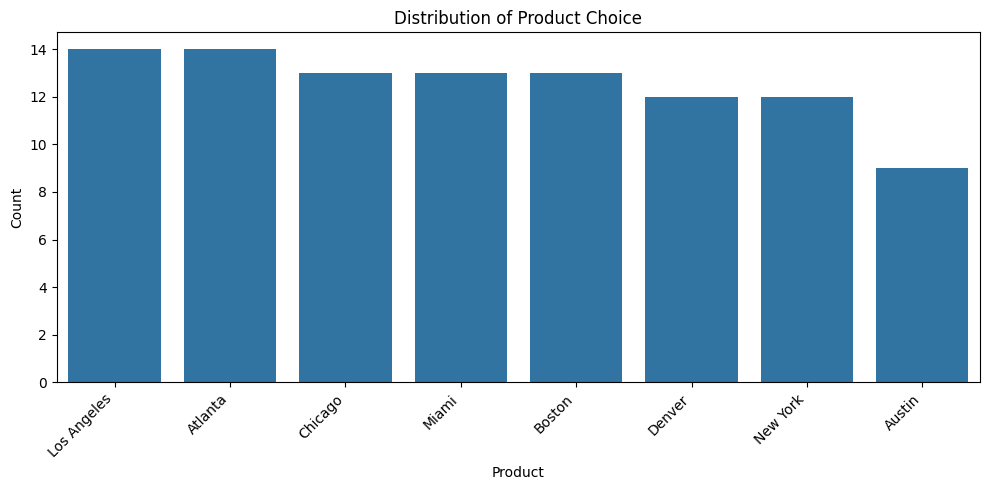

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

feature = "HomeTown"

# Option A – nicest look with almost no code
plt.figure(figsize=(10, 5))          # adjust size as needed
sns.countplot(data=df, 
              x=feature,     # ← change to your column name
              order=df[feature].value_counts().index)  # optional: sort by frequency
plt.title('Distribution of Product Choice')
plt.xlabel(feature)
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')   # readable labels if many/long categories
plt.tight_layout()
plt.show()

In [3]:
# Clean / prepare common issues
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Height'] = pd.to_numeric(df['Height'], errors='coerce')
df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce')
df['Children'] = pd.to_numeric(df['Children'], errors='coerce')
df['InstructionLevel'] = df['InstructionLevel'].astype('category').cat.codes
df['Sex'] = df['Sex'].astype('category').cat.codes
df['ProdChoice'] = df['ProdChoice'].astype('category').cat.codes
df['HomeTown'] = df['HomeTown'].astype('category').cat.codes
df['Interested'] = df['Interested'].astype('category').cat.codes


# Count by product and interest
print("\nProduct choice distribution:")
print(df['ProdChoice'].value_counts())

print("\nInterested by product:")
print(pd.crosstab(df['ProdChoice'], df['Interested']))

# Missing values?
print("\nMissing values:\n", df.isna().sum())

print(df.head())


Product choice distribution:
ProdChoice
0    28
1    25
2    24
3    23
Name: count, dtype: int64

Interested by product:
Interested   0   1
ProdChoice        
0           10  18
1           11  14
2            9  15
3            9  14

Missing values:
 PersonId            0
ProdChoice          0
HomeTown            0
Age                 0
Sex                 0
Children            0
InstructionLevel    0
Height              0
Weight              0
Interested          0
dtype: int64
   PersonId  ProdChoice  HomeTown  Age  Sex  Children  InstructionLevel  \
0         1           0         3   34    1         0                 1   
1         2           2         3   25    0         4                 0   
2         3           1         5   20    0         2                 0   
3         4           3         5   37    0         5                 4   
4         5           2         4   20    1         2                 1   

   Height  Weight  Interested  
0     189      89           1

exploratory analysis

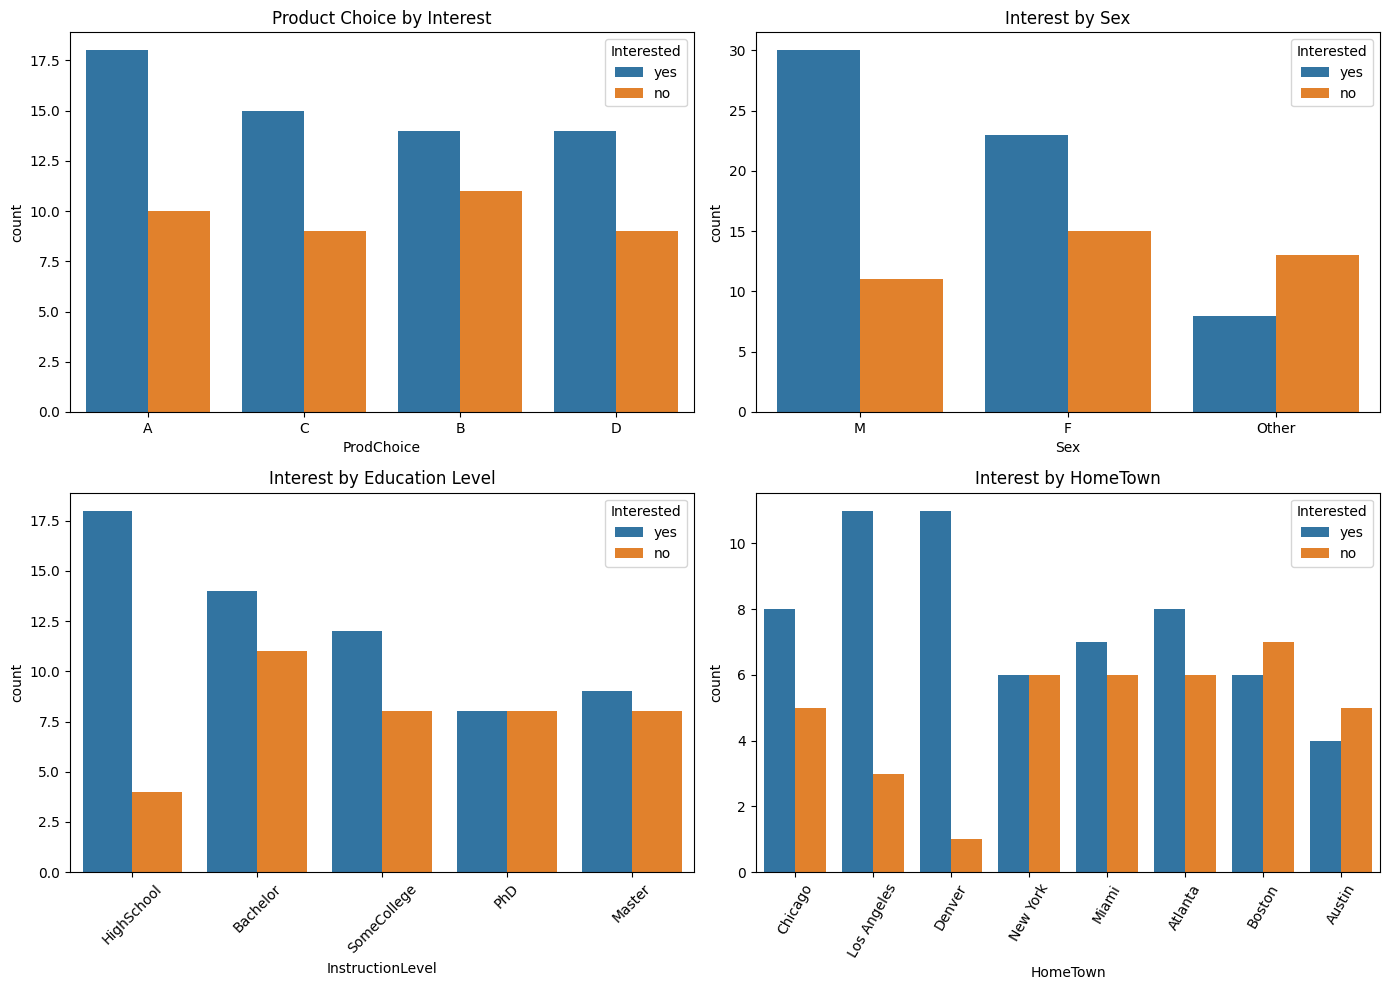

In [ ]:
# 1. Count plots – categorical variables
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
sns.countplot(data=df, x='ProdChoice', hue='Interested')
plt.title("Product Choice by Interest")

plt.subplot(2, 2, 2)
sns.countplot(data=df, x='Sex', hue='Interested')
plt.title("Interest by Sex")

plt.subplot(2, 2, 3)
sns.countplot(data=df, x='InstructionLevel', hue='Interested')
plt.xticks(rotation=45)
plt.title("Interest by Education Level")

plt.subplot(2, 2, 4)
sns.countplot(data=df, x='HomeTown', hue='Interested')
plt.xticks(rotation=60)
plt.title("Interest by HomeTown")

plt.tight_layout()
plt.show()

In [15]:
plt.style.use('seaborn-v0_8-pastel')   # or 'ggplot', 'bmh', etc.
sns.set_palette("muted")

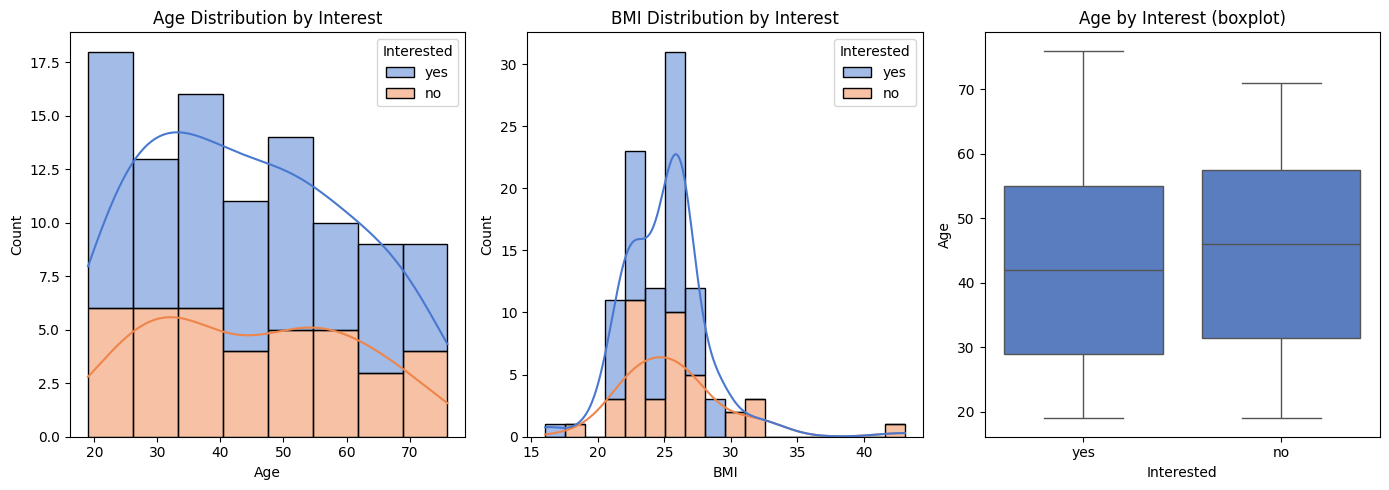

In [16]:
import seaborn as sns
# 2. Age & BMI distributions + relationship with target
plt.figure(figsize=(14, 5))
df['BMI'] = df['Weight'] / ((df['Height']/100) ** 2)

plt.subplot(1, 3, 1)
sns.histplot(data=df, x='Age', kde=True, hue='Interested', multiple='stack')
plt.title("Age Distribution by Interest")

plt.subplot(1, 3, 2)
sns.histplot(data=df, x='BMI', kde=True, hue='Interested', multiple='stack')
plt.title("BMI Distribution by Interest")

plt.subplot(1, 3, 3)
sns.boxplot(data=df, x='Interested', y='Age')
plt.title("Age by Interest (boxplot)")

plt.tight_layout()
plt.show()

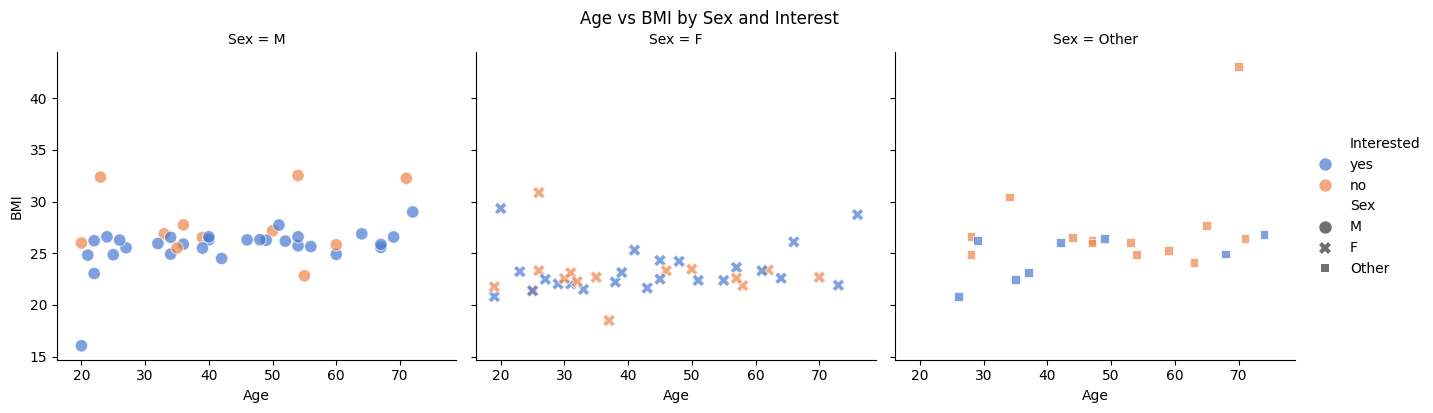

In [17]:
# 3. Age vs BMI – colored by Interested + facet by Sex
g = sns.relplot(
    data=df, x='Age', y='BMI',
    hue='Interested', style='Sex',
    col='Sex', col_wrap=3,
    kind='scatter', s=80, alpha=0.7,
    height=4, aspect=1.1
)
g.set_titles("Sex = {col_name}")
g.fig.suptitle("Age vs BMI by Sex and Interest", y=1.02)
plt.show()

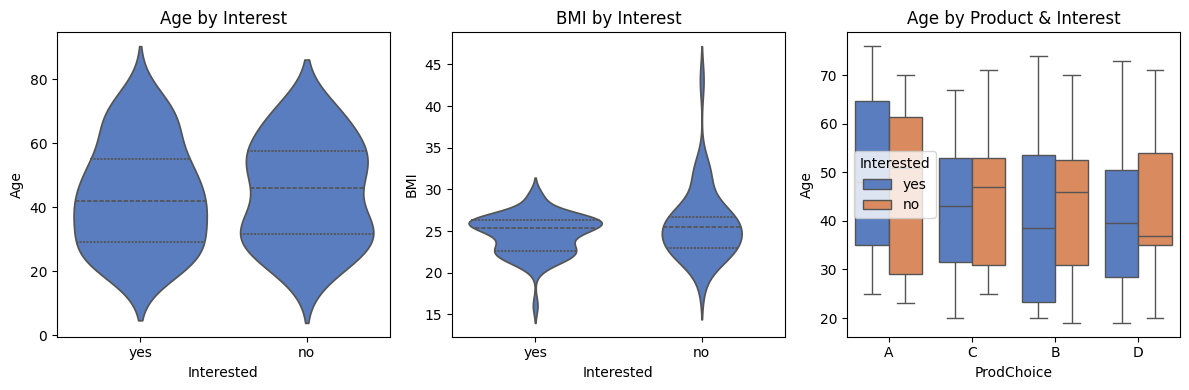

In [18]:
# 4. Violin / box plots – numeric vars vs Interested
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.violinplot(data=df, x='Interested', y='Age', inner='quartile')
plt.title("Age by Interest")

plt.subplot(1, 3, 2)
sns.violinplot(data=df, x='Interested', y='BMI', inner='quartile')
plt.title("BMI by Interest")

plt.subplot(1, 3, 3)
sns.boxplot(data=df, x='ProdChoice', y='Age', hue='Interested')
plt.title("Age by Product & Interest")

plt.tight_layout()
plt.show()

In [ ]:
# 5. Heatmap of correlations (numeric features only)
numeric_cols = ['Age', 'Children', 'Height', 'Weight', 'BMI', 'Interested']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

ValueError: could not convert string to float: 'yes'

In [ ]:
import pandas as pd
import numpy as np
from io import StringIO

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

target = ['Interested','ProdChoice']
X = df.drop(columns=[target])
y = df[target]

# Which columns are categorical vs numeric
categorical_cols = ['ProdChoice', 'HomeTown', 'Sex', 'InstructionLevel']
numeric_cols     = ['Age', 'Children', 'Height', 'Weight']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        solver='lbfgs',
        max_iter=1000,
        class_weight='balanced',      # helps with mild imbalance
        random_state=2025
    ))
])

In [ ]:
# ────────────────────────────────────────────────
# Train / test split (stratified because of imbalance)
# ────────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=2025
)

print(f"Train size: {len(X_train)}   ({len(X_train)/len(X):.0%})")
print(f"Test size : {len(X_test)}    ({len(X_test)/len(X):.0%})")

# ────────────────────────────────────────────────
# Train & predict
# ────────────────────────────────────────────────

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

In [ ]:
# ────────────────────────────────────────────────
# Evaluation
# ────────────────────────────────────────────────

print("\n" + "="*60)
print("TEST PERFORMANCE")
print("="*60)

print(classification_report(y_test, y_pred, digits=3))

print("ROC AUC  :", round(roc_auc_score(y_test, y_pred_proba), 3))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

modeling

feature engineering

correlation between height/weight/age and "Interested"